In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/final_dataset.csv")

df.head()

,district,year,avg_aqi,population,density,literacy,healthcare_facilities
0,Central,2020,338.22,582320,27730,85.1,32
1,Central,2021,249.49,582320,27730,85.1,32
2,Central,2022,243.10,582320,27730,85.1,32
3,Central,2023,196.15,582320,27730,85.1,32
4,East,2017,375.93,1709346,27132,89.3,19


In [3]:
df.describe()

,year,avg_aqi,population,density,literacy,healthcare_facilities
count,29.000000,29.000000,2.900000e+01,29.000000,29.000000,29.000000
mean,2020.517241,236.480690,2.250039e+06,17255.931034,87.024138,30.103448
std,1.805165,46.711628,9.555833e+05,9404.733713,1.910059,6.831361
min,2017.000000,171.410000,5.823200e+05,5446.000000,84.400000,19.000000
25%,2019.000000,196.960000,1.709346e+06,8254.000000,85.100000,30.000000
50%,2021.000000,242.930000,2.292958e+06,19563.000000,87.000000,32.000000
75%,2022.000000,253.720000,2.543243e+06,27132.000000,88.300000,35.000000
max,2023.000000,375.930000,3.656539e+06,27730.000000,89.300000,37.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   district               29 non-null     object 
 1   year                   29 non-null     int64  
 2   avg_aqi                29 non-null     float64
 3   population             29 non-null     int64  
 4   density                29 non-null     int64  
 5   literacy               29 non-null     float64
 6   healthcare_facilities  29 non-null     int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 1.7+ KB


In [4]:
#average AQi
district_aqi = (
    df.groupby("district")["avg_aqi"]
      .mean()
      .sort_values(ascending=False)
)

district_aqi

district
East          275.167143
Central       256.740000
West          248.831667
North West    216.656667
South West    185.313333
Name: avg_aqi, dtype: float64

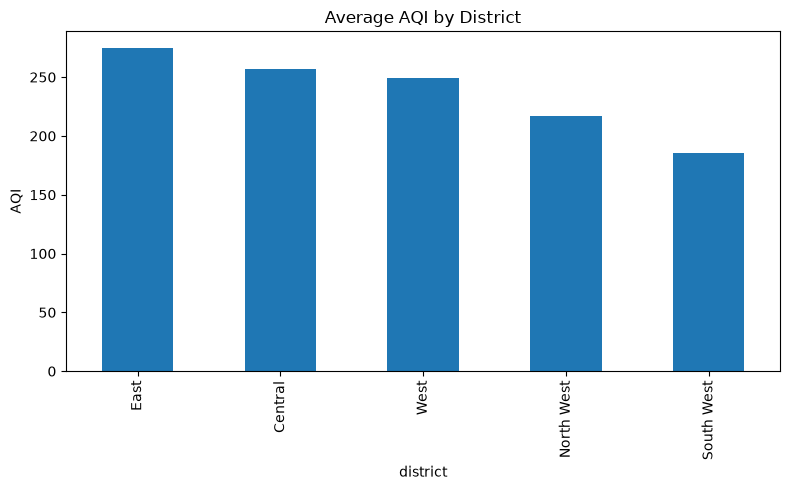

In [5]:
plt.figure(figsize=(8,5))

district_aqi.plot(kind="bar")

plt.title("Average AQI by District")
plt.ylabel("AQI")
plt.tight_layout()

plt.show()

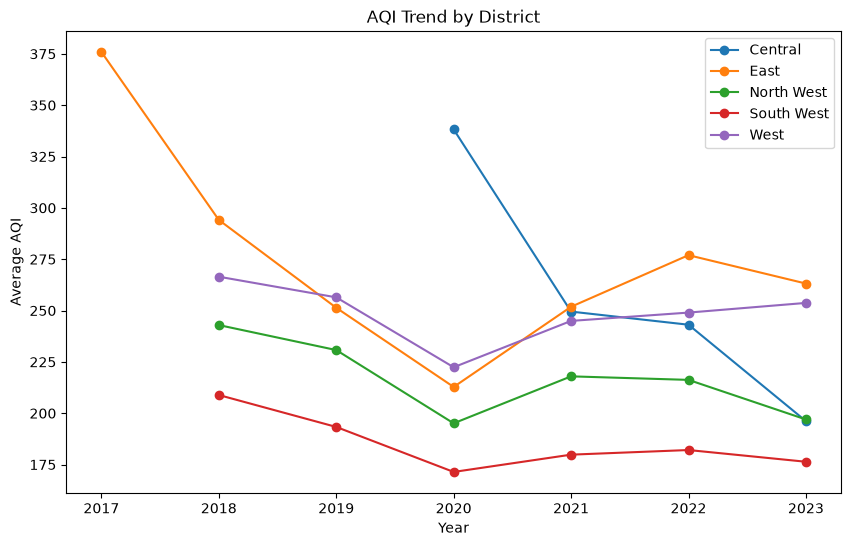

In [6]:
plt.figure(figsize=(10,6))

for district in df["district"].unique():
    temp = df[df["district"] == district]

    plt.plot(
        temp["year"],
        temp["avg_aqi"],
        marker="o",
        label=district
    )

plt.title("AQI Trend by District")
plt.xlabel("Year")
plt.ylabel("Average AQI")

plt.legend()

plt.show()

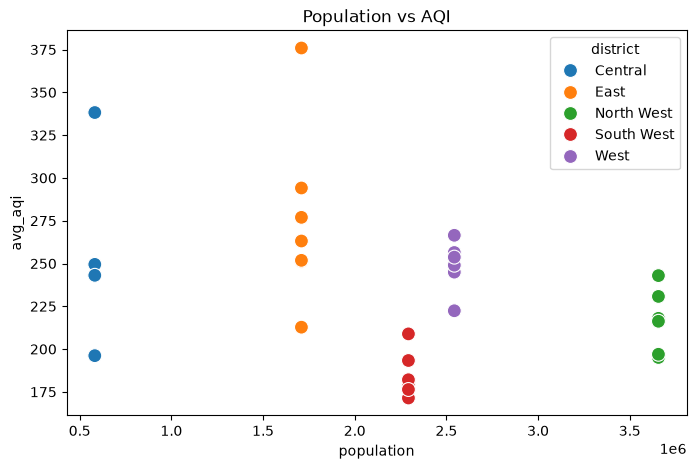

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="population",
    y="avg_aqi",
    hue="district",
    s=100
)

plt.title("Population vs AQI")

plt.show()

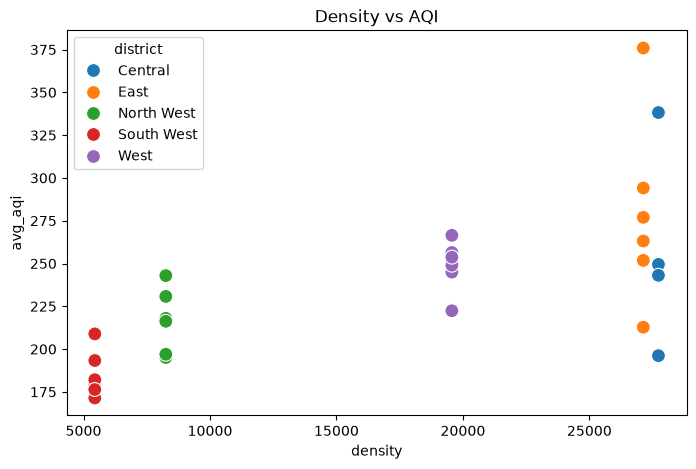

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="density",
    y="avg_aqi",
    hue="district",
    s=100
)

plt.title("Density vs AQI")

plt.show()

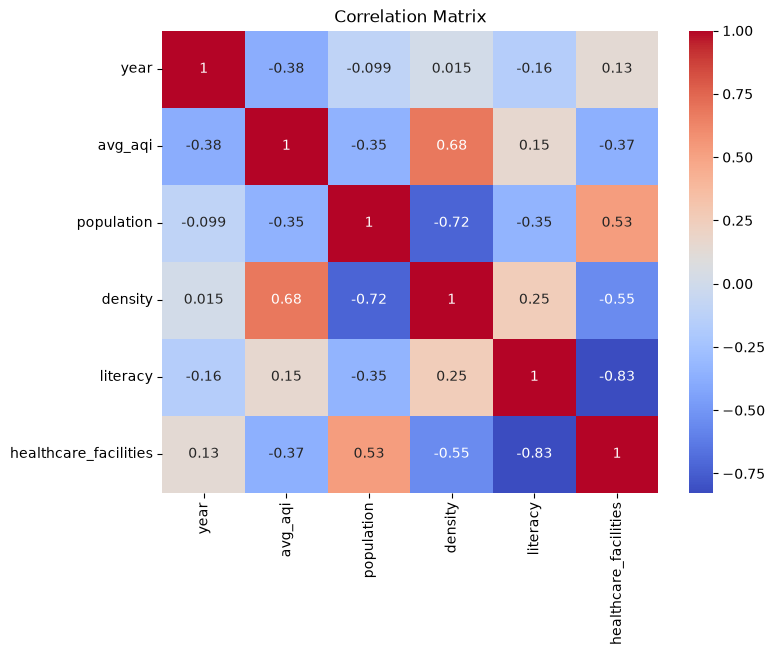

In [8]:
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [11]:
plt.savefig(
    "../outputs/figures/aqi_by_district.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [12]:
df.groupby("district")["year"].agg(["min","max","count"])

,min,max,count
district,,,
Central,2020,2023,4
East,2017,2023,7
North West,2018,2023,6
South West,2018,2023,6
West,2018,2023,6
